In [1]:
import pandas as pd
import polars as pl
pd.set_option('future.no_silent_downcasting', True)
from tensorflow import cast, float32,reduce_mean,maximum
pd.set_option('future.no_silent_downcasting', True)
import numpy as np
import joblib
import gc
inst = joblib.load("../scalers/instituicoes_validas.joblib")
from keras.models import load_model
import matplotlib.pyplot as plt
from funcoes_de_avaliacao import * 
from time import time

windows = ["7-1", "7-2", "14-1", "14-3", "30-7"]
w = windows[1]
if w == windows[0]:
    inputs_day = 7
    outputs_day = 1
    inputs_hour = 7*24
    outputs_hour = 1*24
    inputs_10min = 7*24*6
    outputs_10min = 1*24*6
elif w == windows[1]:
    inputs_day = 7
    outputs_day = 2
    inputs_hour = 7*24
    outputs_hour = 2*24
    inputs_10min = 7*24*6
    outputs_10min = 2*24*6
elif w == windows[2]:
    inputs_day = 14
    outputs_day = 1
    inputs_hour = 14*24
    outputs_hour = 1*24
    inputs_10min = 14*24*6
    outputs_10min = 1*24*6
elif w == windows[3]:
    inputs_day = 14
    outputs_day = 3
    inputs_hour = 14*24
    outputs_hour = 3*24
    inputs_10min = 14*24*6
    outputs_10min = 3*24*6
elif w == windows[4]:
    inputs_day = 30
    outputs_day = 7
    inputs_hour = 30*24
    outputs_hour = 7*24
    inputs_10min = 30*24*6
    outputs_10min = 7*24*6

2026-04-29 11:48:53.998866: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-29 11:48:54.012473: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-29 11:48:54.646197: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-29 11:48:56.025311: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

In [2]:

dim_keys = ["Horario", "Diario", "10minutos"]
model_keys = ["GRU", "LSTM", "RNN"]

modelos ={
    "GRU":{
        "Diario": load_model('../../MODELOS/' + w + '/gru_diaria_otimizada_sem_id.keras', compile=False),
        "Horario": load_model('../../MODELOS/' + w + '/gru_horaria_otimizada_sem_id.keras', compile=False),
        "10minutos": load_model('../../MODELOS/' + w + '/gru_10min_otimizada_sem_id.keras', compile=False)
    },
    "LSTM":{
        "Diario": load_model('../../MODELOS/' + w + '/lstm_diaria_otimizada_sem_id.keras', compile=False),
        "Horario": load_model('../../MODELOS/' + w + '/lstm_horaria_otimizada_sem_id.keras', compile=False),
        "10minutos": load_model('../../MODELOS/' + w + '/lstm_10min_otimizada_sem_id.keras', compile=False)
    },
    "RNN":{
        "Diario": load_model('../../MODELOS/' + w + '/rnn_diaria_otimizada_sem_id.keras', compile=False),
        "Horario": load_model('../../MODELOS/' + w + '/rnn_horaria_otimizada_sem_id.keras', compile=False),
        "10minutos": load_model('../../MODELOS/' + w + '/rnn_10min_otimizada_sem_id.keras', compile=False)
    }
}

E0000 00:00:1777474141.622743 3217862 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1777474141.631177 3217862 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [9]:

test_day_wind = pd.read_csv('../../data/Tabelas_criadas/' + w + '/teste_day.csv')
np_test_d = np.array(test_day_wind)
del test_day_wind
X_test_d = np_test_d[:, :inputs_day + 1].astype('float32')
y_test_d = np_test_d[:, np.r_[inputs_day+1:inputs_day+1+outputs_day,0]].astype('float32')
del np_test_d
gc.collect()

test_hour_wind = pd.read_csv('../../data/Tabelas_criadas/' + w + '/teste_hour.csv')
np_test_h = np.array(test_hour_wind)
del test_hour_wind
X_test_h = np_test_h[:, :inputs_hour + 1].astype('float32')
y_test_h = np_test_h[:, np.r_[inputs_hour+1:inputs_hour+1+outputs_hour,0]].astype('float32')
del np_test_h
gc.collect()

test_10min_wind = pl.read_csv('../../data/Tabelas_criadas/' + w + '/teste_10min.csv')
np_test_10m = test_10min_wind.to_numpy()
del test_10min_wind
X_test_10m = np_test_10m[:, :inputs_10min + 1].astype('float32')
y_test_10m= np_test_10m[:, np.r_[inputs_10min+1:inputs_10min+1+outputs_10min,0]].astype('float32')
del np_test_10m
gc.collect()

0

In [10]:
metricas = {}
for model in model_keys:
    print(model)
    metricas[model] = comparar_desempeho_granularidade(
        X_test_d[:,1:].reshape((X_test_d.shape[0], 1, X_test_d.shape[1]-1)), 
        X_test_h[:,1:].reshape((X_test_h.shape[0], 1, X_test_h.shape[1]-1)),
        X_test_10m[:,1:].reshape((X_test_10m.shape[0], 1, X_test_10m.shape[1]-1)), 
        y_test_d[:,:-1], 
        y_test_h[:,:-1],
        y_test_10m[:,:-1],
        modelos[model]["Diario"],
        modelos[model]["Horario"],
        modelos[model]["10minutos"]
    )

GRU
Carregando modelos...
Desempenho do modelo para granularidade diária:
--- Desempenho: ---
RMSE (Erro Médio): 0.2478
MAE  (Erro Absoluto): 0.2090
SMAPE: 34.9860
NRMSE: 0.1921
Tempo de avaliação: 0.18038057605735958 segundos para 4040 amostras
------------------------------
Desempenho do modelo para granularidade horária:
--- Desempenho: ---
RMSE (Erro Médio): 0.1055
MAE  (Erro Absoluto): 0.0688
SMAPE: 52.0300
NRMSE: 0.0191
Tempo de avaliação: 0.770020543015562 segundos para 2224896 amostras
------------------------------
Desempenho do modelo para granularidade 10minutos:
--- Desempenho: ---
RMSE (Erro Médio): 0.0764
MAE  (Erro Absoluto): 0.0355
SMAPE: 54.5485
NRMSE: 0.0764
Tempo de avaliação: 8.298004454001784 segundos para 79585056 amostras
------------------------------
LSTM
Carregando modelos...
Desempenho do modelo para granularidade diária:
--- Desempenho: ---
RMSE (Erro Médio): 0.2479
MAE  (Erro Absoluto): 0.2092
SMAPE: 34.7074
NRMSE: 0.1921
Tempo de avaliação: 0.1689724249299

In [12]:

predicoes = {}
predicoes_sem_escaler = {}
real = {
    "Diario": y_test_d[:,:-1],
    "Horario": y_test_h[:,:-1],
    "10minutos": y_test_10m[:,:-1]
}
for model in model_keys:
    print(model)
    predicoes[model] = {
        "Diario": modelos[model]["Diario"].predict(X_test_d[:,1:].reshape((X_test_d.shape[0], 1, X_test_d.shape[1]-1))),
        "Horario": modelos[model]["Horario"].predict(X_test_h[:,1:].reshape((X_test_h.shape[0], 1, X_test_h.shape[1]-1))),
        "10minutos": modelos[model]["10minutos"].predict(X_test_10m[:,1:].reshape((X_test_10m.shape[0], 1, X_test_10m.shape[1]-1)))
    }
        

GRU
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 511us/step
1449/1449 ━━━━━━━━━━━━━━━━━━━━ 1s 465us/step
8636/8636 ━━━━━━━━━━━━━━━━━━━━ 8s 948us/step
LSTM
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 424us/step
1449/1449 ━━━━━━━━━━━━━━━━━━━━ 1s 426us/step
8636/8636 ━━━━━━━━━━━━━━━━━━━━ 8s 956us/step
RNN
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 429us/step
1449/1449 ━━━━━━━━━━━━━━━━━━━━ 0s 292us/step
8636/8636 ━━━━━━━━━━━━━━━━━━━━ 4s 453us/step


### Desescalonando dias preditos

In [16]:
scalers_day = joblib.load('../scalers/scalers_day.joblib')
ids_instituicoes = X_test_d[:, 0]
instituicoes_unicas = np.unique(ids_instituicoes)

real_sem_escaler = {}
for model in model_keys:
    if model not in predicoes_sem_escaler:
        predicoes_sem_escaler[model] = {}
        
    preds_originais = predicoes[model]["Diario"]
    real_originais = real["Diario"]
    
    # Listas temporárias para guardar os dados limpos e as posições originais deles
    linhas_revertidas = []
    indices_originais = []
    linhas_revertidas_real = []
    indices_originais_real = []

    for i in instituicoes_unicas:
        # Pega as posições exatas (números das linhas) onde esta instituição aparece na matriz original
        indices_inst = np.where(ids_instituicoes == i)[0]

        # Aplica o salto de 24 em 24 apenas nesses índices
        indices_filtrados = indices_inst

        if len(indices_filtrados) > 0:
            scaler = scalers_day[str(int(i))]
            
            # Puxa os dados da matriz original usando os índices já filtrados
            dados_inst_filtrado = preds_originais[indices_filtrados]
            real_inst_filtrado = real_originais[indices_filtrados]

            # Achata, desnormaliza e devolve para o formato de colunas
            dados_achatados = dados_inst_filtrado.reshape(-1, 1)
            dados_revertidos = scaler.inverse_transform(dados_achatados).reshape(dados_inst_filtrado.shape)
            real_achatados = real_inst_filtrado.reshape(-1, 1)
            real_revertidos = scaler.inverse_transform(real_achatados).reshape(real_inst_filtrado.shape)

            # Guarda os dados revertidos e anota a posição original de cada um
            linhas_revertidas.extend(dados_revertidos)
            indices_originais.extend(indices_filtrados)
            linhas_revertidas_real.extend(real_revertidos)
            indices_originais_real.extend(indices_filtrados)

    # Converte as listas de volta para matrizes do NumPy
    linhas_revertidas = np.array(linhas_revertidas)
    indices_originais = np.array(indices_originais)
    linhas_revertidas_real = np.array(linhas_revertidas_real)
    indices_originais_real = np.array(indices_originais_real)

    # O PASSO FUNDAMENTAL: Descobre a ordem correta para reembaralhar os dados de volta ao formato cronológico
    ordem_correta = np.argsort(indices_originais)
    
    # Salva a matriz perfeita, desnormalizada, filtrada e ordenada
    predicoes_sem_escaler[model]["Diario"] = linhas_revertidas[ordem_correta]
    real_sem_escaler["Diario"] = linhas_revertidas_real[np.argsort(indices_originais_real)]


### Desescalonando Horário

In [17]:
import numpy as np
scalers_hour = joblib.load('../scalers/scalers_hour.joblib')
ids_instituicoes = X_test_h[:, 0]
instituicoes_unicas = np.unique(ids_instituicoes)

for model in model_keys:
    preds_originais = predicoes[model]["Horario"]
    real_originais = real["Horario"]
    
    # Listas temporárias para guardar os dados limpos e as posições originais deles
    linhas_revertidas = []
    indices_originais = []
    linhas_revertidas_real = []
    indices_originais_real = []

    for i in instituicoes_unicas:
        # Pega as posições exatas (números das linhas) onde esta instituição aparece na matriz original
        indices_inst = np.where(ids_instituicoes == i)[0]

        # Aplica o salto de 24 em 24 apenas nesses índices
        indices_filtrados = indices_inst

        if len(indices_filtrados) > 0:
            scaler = scalers_hour[str(int(i))]
            
            # Puxa os dados da matriz original usando os índices já filtrados
            dados_inst_filtrado = preds_originais[indices_filtrados]
            real_inst_filtrado = real_originais[indices_filtrados]

            # Achata, desnormaliza e devolve para o formato de colunas
            dados_achatados = dados_inst_filtrado.reshape(-1, 1)
            dados_revertidos = scaler.inverse_transform(dados_achatados).reshape(dados_inst_filtrado.shape)
            real_achatados = real_inst_filtrado.reshape(-1, 1)
            real_revertidos = scaler.inverse_transform(real_achatados).reshape(real_inst_filtrado.shape)

            # Guarda os dados revertidos e anota a posição original de cada um
            linhas_revertidas.extend(dados_revertidos)
            indices_originais.extend(indices_filtrados)
            linhas_revertidas_real.extend(real_revertidos)
            indices_originais_real.extend(indices_filtrados)

    # Converte as listas de volta para matrizes do NumPy
    linhas_revertidas = np.array(linhas_revertidas)
    indices_originais = np.array(indices_originais)
    linhas_revertidas_real = np.array(linhas_revertidas_real)
    indices_originais_real = np.array(indices_originais_real)

    # O PASSO FUNDAMENTAL: Descobre a ordem correta para reembaralhar os dados de volta ao formato cronológico
    ordem_correta = np.argsort(indices_originais)
    
    # Salva a matriz perfeita, desnormalizada, filtrada e ordenada
    predicoes_sem_escaler[model]["Horario"] = linhas_revertidas[ordem_correta]
    real_sem_escaler["Horario"] = linhas_revertidas_real[np.argsort(indices_originais_real)]

### Desescalonando minutos

In [18]:

scalers_10min = joblib.load('../scalers/scalers_10min.joblib')
ids_instituicoes = X_test_10m[:, 0]
instituicoes_unicas = np.unique(ids_instituicoes)

for model in model_keys:
    preds_originais = predicoes[model]["10minutos"]
    real_originais = real["10minutos"]
    
    # Listas temporárias para guardar os dados limpos e as posições originais deles
    linhas_revertidas = []
    indices_originais = []
    linhas_revertidas_real = []
    indices_originais_real = []

    for i in instituicoes_unicas:
        # Pega as posições exatas (números das linhas) onde esta instituição aparece na matriz original
        indices_inst = np.where(ids_instituicoes == i)[0]

        # Aplica o salto de 24 em 24 apenas nesses índices
        indices_filtrados = indices_inst

        if len(indices_filtrados) > 0:
            scaler = scalers_10min[str(int(i))]
            
            # Puxa os dados da matriz original usando os índices já filtrados
            dados_inst_filtrado = preds_originais[indices_filtrados]
            real_inst_filtrado = real_originais[indices_filtrados]

            # Achata, desnormaliza e devolve para o formato de colunas
            dados_achatados = dados_inst_filtrado.reshape(-1, 1)
            dados_revertidos = scaler.inverse_transform(dados_achatados).reshape(dados_inst_filtrado.shape)
            real_achatados = real_inst_filtrado.reshape(-1, 1)
            real_revertidos = scaler.inverse_transform(real_achatados).reshape(real_inst_filtrado.shape)

            # Guarda os dados revertidos e anota a posição original de cada um
            linhas_revertidas.extend(dados_revertidos)
            indices_originais.extend(indices_filtrados)
            linhas_revertidas_real.extend(real_revertidos)
            indices_originais_real.extend(indices_filtrados)

    # Converte as listas de volta para matrizes do NumPy
    linhas_revertidas = np.array(linhas_revertidas)
    indices_originais = np.array(indices_originais)
    linhas_revertidas_real = np.array(linhas_revertidas_real)
    indices_originais_real = np.array(indices_originais_real)

    # O PASSO FUNDAMENTAL: Descobre a ordem correta para reembaralhar os dados de volta ao formato cronológico
    ordem_correta = np.argsort(indices_originais)
    
    # Salva a matriz perfeita, desnormalizada, filtrada e ordenada
    predicoes_sem_escaler[model]["10minutos"] = linhas_revertidas[ordem_correta]
    real_sem_escaler["10minutos"] = linhas_revertidas_real[np.argsort(indices_originais_real)]

## Plotando os gráficos

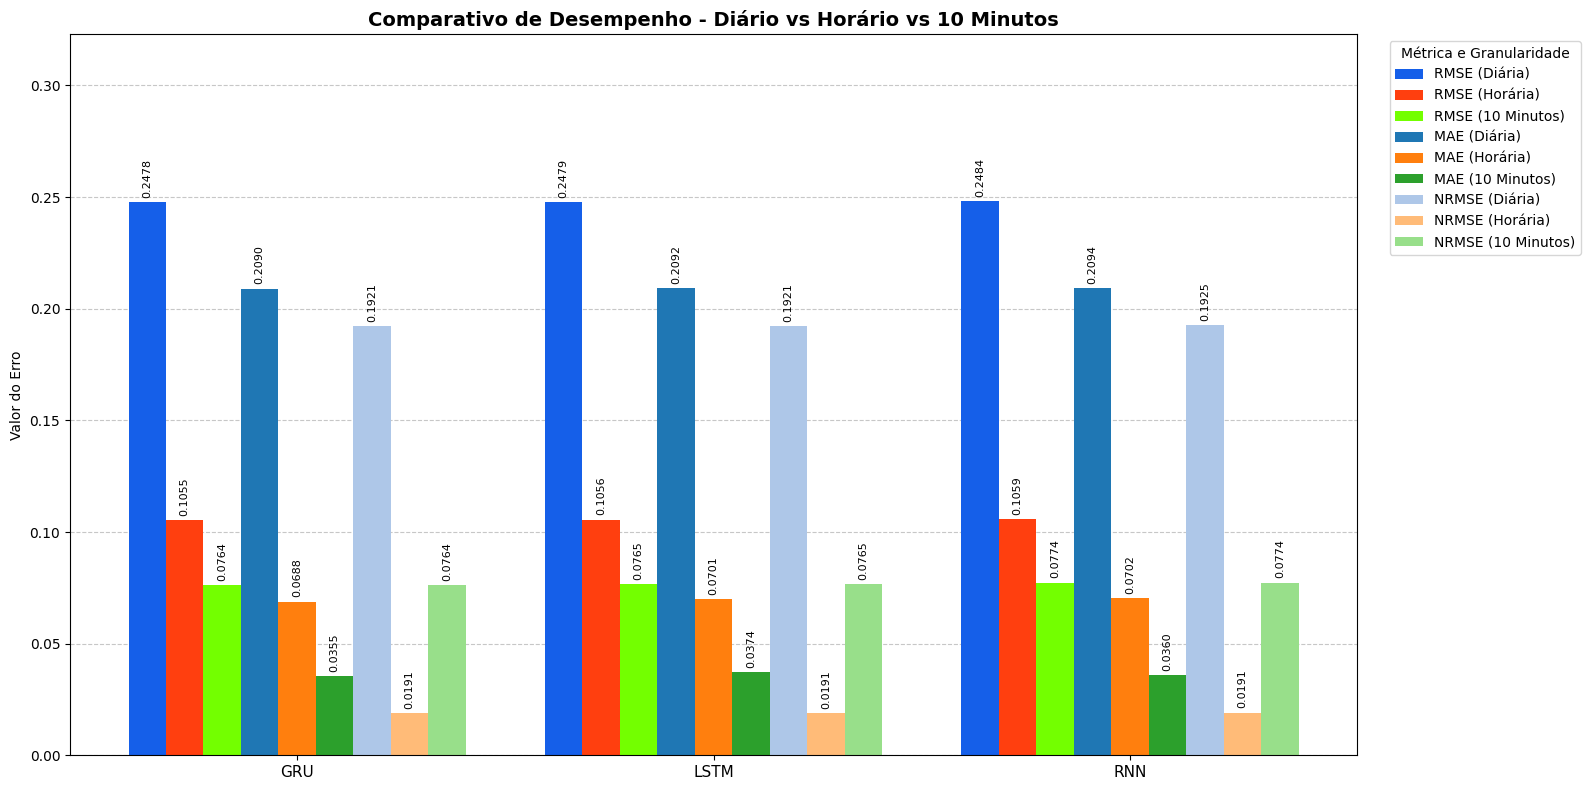

In [19]:
modelos = list(metricas.keys())
metricas_plot = ['RMSE','MAE', 'NRMSE'] 

# Adição de um terceiro tom (mais claro) para a granularidade de 10 minutos


cores = {
    'RMSE': {'Diario': "#155fe9", 'Horario': "#ff3f0f", '10minutos:': "#73ff00"},
    'MAE': {'Diario': '#1f77b4', 'Horario': '#ff7f0e', '10minutos:': '#2ca02c'},
    'NRMSE': {'Diario': '#aec7e8', 'Horario': '#ffbb78', '10minutos:': '#98df8a'},
}

# Configuração do espaçamento das 9 barras
x = np.arange(len(modelos))

# A largura da barra foi reduzida para 0.09. 
# Assim, 9 barras ocupam 0.81 do espaço, deixando uma margem limpa entre os modelos.
largura_barra = 0.09  
offsets = [-4, -3, -2, -1, 0, 1, 2, 3, 4] 

fig, ax = plt.subplots(figsize=(16, 8)) # Figura levemente mais larga

idx_offset = 0
for metrica in metricas_plot:
    for granularidade in ['Diario', 'Horario', '10minutos:']:
        valores = [metricas[modelo][granularidade][metrica] for modelo in modelos]
        posicao = x + (offsets[idx_offset] * largura_barra)
        
        # Ajuste dinâmico do nome para a legenda
        if granularidade == "Diario":
            nome_gran = "Diária"
        elif granularidade == "Horario":
            nome_gran = "Horária"
        else:
            nome_gran = "10 Minutos"
            
        label = f'{metrica} ({nome_gran})'
        cor = cores[metrica][granularidade]
        
        barras = ax.bar(posicao, valores, largura_barra, label=label, color=cor)
        
        # Valores no topo
        ax.bar_label(barras, padding=3, fmt='%.4f', fontsize=8, rotation=90)
        idx_offset += 1

ax.set_ylabel('Valor do Erro')
ax.set_title('Comparativo de Desempenho - Diário vs Horário vs 10 Minutos', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(modelos, fontsize=11)

ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True) 

# Ajuste automático e seguro do limite Y para evitar corte dos números rotacionados
valor_maximo = max([metricas[mod][gran][met] for mod in modelos for gran in ['Diario', 'Horario', '10minutos:'] for met in metricas_plot])
ax.set_ylim(0, valor_maximo * 1.3)

ax.legend(title='Métrica e Granularidade', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

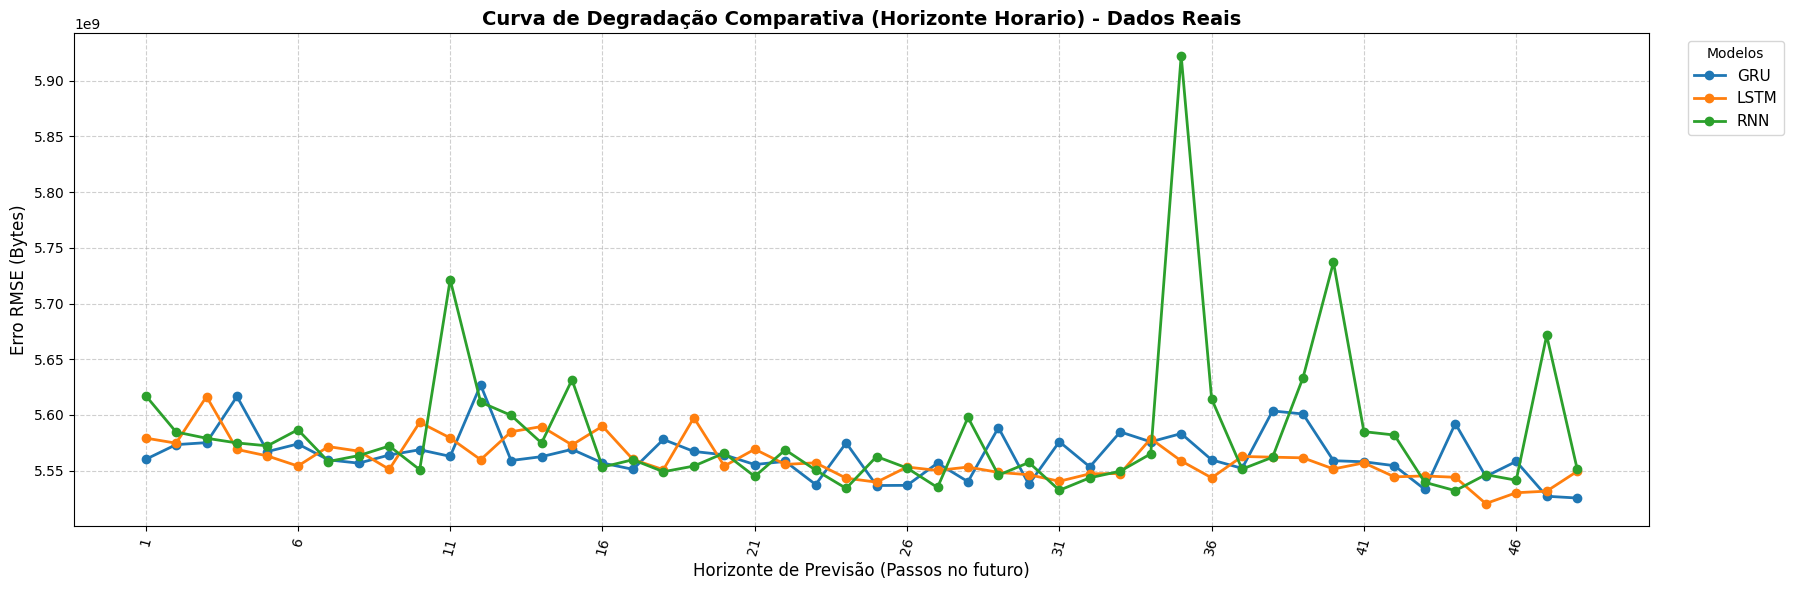

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

granularidade = {
    "Diario":outputs_day,
    "Horario": outputs_hour,
    "10minutos": outputs_10min
}

# Define qual granularidade você quer plotar neste gráfico
gran = "Horario"

# 1. Cria a figura UMA ÚNICA VEZ antes do loop
plt.figure(figsize=(18, 6))

# 2. Loop para cada modelo: calcula os erros e adiciona a linha no gráfico aberto
for modelo in model_keys:
    erros_por_horizonte = []

    # Calcula o erro separadamente para cada passo no futuro
    for t in range(granularidade[gran]):
        real_coluna = real_sem_escaler[gran][:, t]
        pred_coluna = predicoes_sem_escaler[modelo][gran][:, t]

        # Calcula o RMSE dessa hora específica
        rmse_atual = np.sqrt(mean_squared_error(real_coluna, pred_coluna))
        erros_por_horizonte.append(rmse_atual)

    # Plota a linha deste modelo (o parâmetro 'label' garante que o nome vá para a legenda)
    plt.plot(range(1, granularidade[gran] + 1), erros_por_horizonte, marker='o', linewidth=2, label=modelo)

# 3. Estilização do gráfico unificado
plt.title(f'Curva de Degradação Comparativa (Horizonte {gran}) - Dados Reais', fontsize=14, fontweight='bold')
plt.xlabel('Horizonte de Previsão (Passos no futuro)', fontsize=12)
plt.ylabel('Erro RMSE (Bytes)', fontsize=12)

# Configura o eixo X para mostrar todos os passos
plt.xticks(range(1, granularidade[gran] + 1,5), rotation = 75)
plt.grid(True, linestyle='--', alpha=0.6)

# Invoca a legenda para mostrar qual cor pertence a qual modelo
plt.legend(title='Modelos', fontsize=11, loc='upper left', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

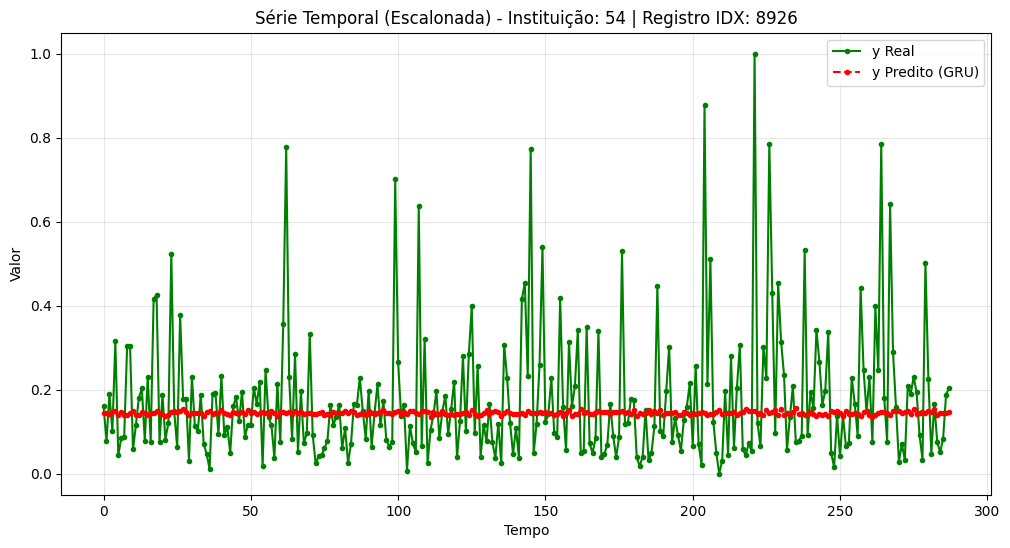

In [44]:
import matplotlib.pyplot as plt
import random

# Escolher um modelo, uma granularidade e uma instituição aleatória
modelo_escolhido = 'GRU'
gran_escolhida = '10minutos'
inputs = inputs_hour # Alterar para inputs_day ou inputs_10min conforme a granularidade
outputs = outputs_hour

ids_instituicoes = X_test_h[:, 0]
instituicoes_unicas = np.unique(ids_instituicoes)
inst_escolhida = random.choice(instituicoes_unicas)

# Encontrar os índices onde essa instituição aparece
indices_inst = np.where(ids_instituicoes == inst_escolhida)[0]
if len(indices_inst) > 0:
    # Escolher um registro aleatório dessa instituição
    idx_registro = random.choice(indices_inst)
    
    # Extrair X, y_real e y_predito (usando os dados em escala)
    y_real_registro = real[gran_escolhida][idx_registro, :]
    y_pred_registro = predicoes[modelo_escolhido][gran_escolhida][idx_registro, :]
    
    # Criar eixo de tempo (x-axis)
    t_y = np.arange(len(y_real_registro))
    
    # Plot
    plt.figure(figsize=(12, 6))

    plt.plot(t_y, y_real_registro, label='y Real', color='green', marker='.')
    plt.plot(t_y, y_pred_registro, label=f'y Predito ({modelo_escolhido})', color='red', marker='.', linestyle='--')
    

    plt.title(f'Série Temporal (Escalonada) - Instituição: {int(inst_escolhida)} | Registro IDX: {idx_registro}')
    plt.xlabel('Tempo')
    plt.ylabel('Valor')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Nenhum registro encontrado para essa instituição.")
